
Example 1 : ('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same') => Yes
S = [('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same')]
G = [('?', '?', '?', '?', '?', '?')]

Example 2 : ('Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same') => Yes
S = [('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')]
G = [('?', '?', '?', '?', '?', '?')]

Example 3 : ('Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change') => No
S = [('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')]
G = [('?', '?', '?', '?', '?', 'Same'), ('?', 'Warm', '?', '?', '?', '?'), ('Sunny', '?', '?', '?', '?', '?')]

Example 4 : ('Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change') => Yes
S = [('Sunny', 'Warm', '?', 'Strong', '?', '?')]
G = [('?', 'Warm', '?', '?', '?', '?'), ('Sunny', '?', '?', '?', '?', '?')]

FINAL SPECIFIC BOUNDARY
('Sunny', 'Warm', '?', 'Strong', '?', '?')

FINAL GENERAL BOUNDARY
('?', 'Warm', '?', '?', '?', '?')
('Sunny', '?', '?', '?', '?', '?')


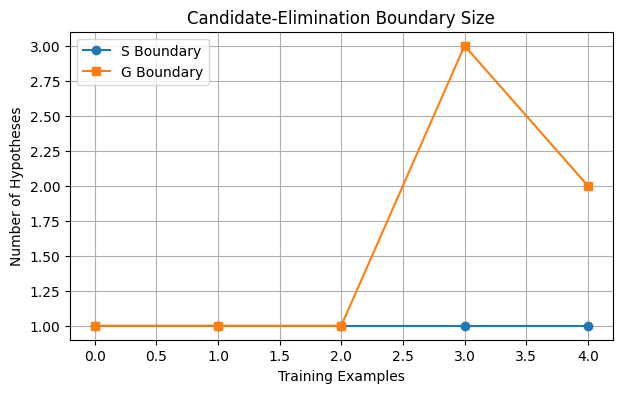

Text(0.5, 1.0, 'Generalization in Final Boundaries')

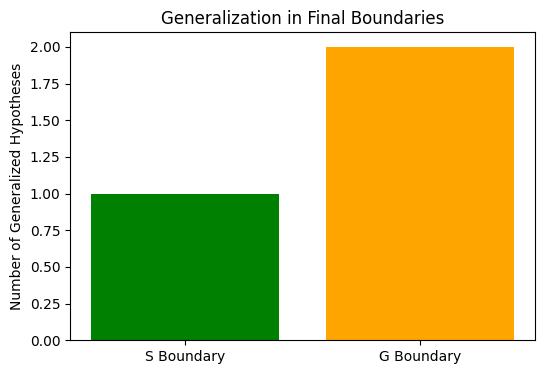

In [2]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DATASET
# ---------------------------------------------------------

attributes = ['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast']

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n = len(attributes)


# ---------------------------------------------------------
# 2. HELPER FUNCTIONS
# ---------------------------------------------------------

def consistent(h, x):
    for a, b in zip(h, x):
        if a != '?' and a != b:
            return False
    return True


def more_general(h1, h2):
    for a, b in zip(h1, h2):
        if a != '?' and a != b:
            return False
    return True


def generalize(s, x):
    s = list(s)

    for i in range(n):
        if s[i] == '0':
            s[i] = x[i]
        elif s[i] != x[i]:
            s[i] = '?'

    return tuple(s)


def specialize(g, x):
    result = []

    for i in range(n):
        if g[i] == '?':
            # Use another possible value
            values = set(row[i] for row in X)

            for value in values:
                if value != x[i]:
                    new_g = list(g)
                    new_g[i] = value
                    result.append(tuple(new_g))

    return result


# ---------------------------------------------------------
# 3. CANDIDATE ELIMINATION
# ---------------------------------------------------------

S = [tuple(['0'] * n)]
G = [tuple(['?'] * n)]

S_history = [len(S)]
G_history = [len(G)]

for i in range(len(X)):

    x = tuple(X[i])
    label = y[i]

    print("\nExample", i + 1, ":", x, "=>", label)

    if label == 'Yes':

        # Remove G hypotheses that don't cover positive example
        G = [g for g in G if consistent(g, x)]

        new_S = []

        for s in S:

            if consistent(s, x):
                new_S.append(s)

            else:
                new_s = generalize(s, x)

                # Keep only if it is covered by some G
                if any(more_general(g, new_s) for g in G):
                    new_S.append(new_s)

        S = list(set(new_S))

    else:

        # Remove S hypotheses that cover negative example
        S = [s for s in S if not consistent(s, x)]

        new_G = []

        for g in G:

            if not consistent(g, x):
                new_G.append(g)

            else:
                specializations = specialize(g, x)

                for h in specializations:
                    if any(more_general(h, s) for s in S):
                        new_G.append(h)

        G = list(set(new_G))

    S_history.append(len(S))
    G_history.append(len(G))

    print("S =", S)
    print("G =", G)


# ---------------------------------------------------------
# 4. FINAL RESULT
# ---------------------------------------------------------

print("\n==========================")
print("FINAL SPECIFIC BOUNDARY")
print("==========================")

for s in S:
    print(s)

print("\n==========================")
print("FINAL GENERAL BOUNDARY")
print("==========================")

for g in G:
    print(g)


# ---------------------------------------------------------
# 5. GRAPH 1 - BOUNDARY SIZE
# ---------------------------------------------------------

examples = range(len(S_history))

plt.figure(figsize=(7, 4))

plt.plot(examples, S_history,
         marker='o', label='S Boundary')

plt.plot(examples, G_history,
         marker='s', label='G Boundary')

plt.xlabel("Training Examples")
plt.ylabel("Number of Hypotheses")
plt.title("Candidate-Elimination Boundary Size")

plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 6. GRAPH 2 - GENERALIZATION
# ---------------------------------------------------------

def count_questions(boundary):
    if not boundary:
        return 0

    return sum(
        '?' in hypothesis
        for hypothesis in boundary
    )


s_general = count_questions(S)
g_general = count_questions(G)

plt.figure(figsize=(6, 4))

plt.bar(
    ['S Boundary', 'G Boundary'],
    [s_general, g_general],
    color=['green', 'orange']
)

plt.ylabel("Number of Generalized Hypotheses")
plt.title("Generalization in Final Boundaries")